In [1]:
from pathlib import Path

import pandas as pd

import quantnado
from quantnado.analysis.core import QuantNadoDataset

In [2]:
OUT_DIR = Path("profiling_output")
SAMPLES_DIR = OUT_DIR / "samples"
GTF_FILE = "local/gencode.v49.annotation.gtf"

### Make datasets

In [3]:
md_path = Path(OUT_DIR) / "quantnado_metadata.csv"

if md_path.exists():
    print(f"Metadata file exists: {md_path}")
    metadata = pd.read_csv(md_path)
else:
    metadata = (
        quantnado.metadata_from_seqnado("/Users/catherine/work/datasets", output_dir=OUT_DIR)
        .sort_values("sample_id")
        .groupby("assay")
        .head(2)
        .reset_index(drop=True)
    )

    mcc_row = pd.DataFrame(
        [
            {
                "assay": "MCC",
                "sample_id": "MCC-OCI-AML3",
                "bam_path": "tests/data/OCI-AML3-control-1-1-A_subsample.bam",
            }
        ]
    ).reindex(columns=metadata.columns)

    metadata = pd.concat([metadata, mcc_row], ignore_index=True)
    metadata.to_csv(md_path, index=False)

metadata

Metadata file exists: profiling_output/quantnado_metadata.csv


,assay,sample_id,ip,bam_path,stranded,methylation_path,variant_path
0,ATAC,ATAC-SEM-1,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
1,ATAC,ATAC-SEM-2,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
2,CUT&TAG,CAT-HSC_H3K27ac,H3K27ac,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
3,CUT&TAG,CAT-HSC_MLLN,MLLN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
4,ChIP,CM-RCHACV-1_MLLN,MLLN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
5,ChIP,CM-RCHACV-1_Menin,Menin,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
6,RNA,RNA-RCHACV-1,NaN,/Users/catherine/work/datasets/seqnado_output/...,R,NaN,NaN
7,RNA,RNA-RCHACV-2,NaN,/Users/catherine/work/datasets/seqnado_output/...,R,NaN,NaN
8,METH,TAPS-RCHACV,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN
9,METH,TAPS-RS411,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN


In [4]:
for _, row in metadata.iterrows():
    sample = row["sample_id"]
    assay = row["assay"]
    store = Path(SAMPLES_DIR / f"{sample}.zarr")

    if not store.exists():
        print(f"Processing {sample} ({assay})...")
        quantnado.create_dataset(
            sample_id=sample,
            assay=assay,
            output_path=store,
            bam_path=row.get("bam_path"),
            methyl_path=row.get("methylation_path"),
            variants_path=row.get("variant_path"),
        )
    else:
        print(f"Store exists: {sample} ({assay})")

Store exists: ATAC-SEM-1 (ATAC)
Store exists: ATAC-SEM-2 (ATAC)
Store exists: CAT-HSC_H3K27ac (CUT&TAG)
Store exists: CAT-HSC_MLLN (CUT&TAG)
Store exists: CM-RCHACV-1_MLLN (ChIP)
Store exists: CM-RCHACV-1_Menin (ChIP)
Store exists: RNA-RCHACV-1 (RNA)
Store exists: RNA-RCHACV-2 (RNA)
Store exists: TAPS-RCHACV (METH)
Store exists: TAPS-RS411 (METH)
Store exists: gDNA-RCHACV (SNP)
Store exists: gDNA-SEM (SNP)
Store exists: MCC-OCI-AML3 (MCC)


### Combine

In [5]:
output_path = OUT_DIR / "dataset.zarr"
if not output_path.exists():
    QuantNadoDataset.combine(src=SAMPLES_DIR, output=output_path)

### Open zarr

In [6]:
qn = QuantNadoDataset(output_path)

### Properties

In [7]:
print("Sample names:\n", qn.sample_names)  # list[str]
print("Assays:\n", qn.assays)  # list[str]  — array keys present across stores
print("Chromosomes:\n", qn.chromosomes)  # list[str]  — excludes 'metadata' group
print("Chromsizes:\n", qn.chromsizes)  # dict[str, int]

Sample names:
 ['ATAC-SEM-1', 'ATAC-SEM-2', 'CAT-HSC_H3K27ac', 'CAT-HSC_MLLN', 'CM-RCHACV-1_MLLN', 'CM-RCHACV-1_Menin', 'MCC-OCI-AML3_ABCA2', 'MCC-OCI-AML3_ARID1B', 'MCC-OCI-AML3_ASAP2', 'MCC-OCI-AML3_ASXL1', 'MCC-OCI-AML3_BCL11A', 'MCC-OCI-AML3_BCL2', 'MCC-OCI-AML3_BRD4', 'MCC-OCI-AML3_CASP2', 'MCC-OCI-AML3_CD38', 'MCC-OCI-AML3_CDC25A', 'MCC-OCI-AML3_CDK6', 'MCC-OCI-AML3_CXCR4', 'MCC-OCI-AML3_DNMT3A', 'MCC-OCI-AML3_E2F1', 'MCC-OCI-AML3_ERG', 'MCC-OCI-AML3_EXO1', 'MCC-OCI-AML3_EZH2', 'MCC-OCI-AML3_FLT3', 'MCC-OCI-AML3_FOS', 'MCC-OCI-AML3_GFI1', 'MCC-OCI-AML3_GNAQ', 'MCC-OCI-AML3_HIVEP2', 'MCC-OCI-AML3_IDH1', 'MCC-OCI-AML3_IKZF1', 'MCC-OCI-AML3_JAK2', 'MCC-OCI-AML3_JMJD1C', 'MCC-OCI-AML3_JUN', 'MCC-OCI-AML3_KRAS', 'MCC-OCI-AML3_LMO4', 'MCC-OCI-AML3_MBNL1', 'MCC-OCI-AML3_MCM3', 'MCC-OCI-AML3_MEF2C', 'MCC-OCI-AML3_MEF2D', 'MCC-OCI-AML3_MEIS1', 'MCC-OCI-AML3_MSL3', 'MCC-OCI-AML3_MYC', 'MCC-OCI-AML3_NF1', 'MCC-OCI-AML3_PAX5', 'MCC-OCI-AML3_PROM1', 'MCC-OCI-AML3_PTPN11', 'MCC-OCI-AML3_RUNX1'

### Region slice 

→ xr.Dataset  (1-based coords)

In [8]:
region = qn.sel(chrom="chr21", start=1_000_000, end=1_001_000)
region
# xr.Dataset
#   dims:      sample × position
#   coords:    position=[1000000..1001000]  (1-based), sample=[...]
#   data_vars: atac, chip_h3k27ac, rna_fwd, rna_rev, coverage, methyl_pct, GT, ...

<xarray.Dataset> Size: 29MB
Dimensions:       (sample: 61, position: 1001)
Coordinates:
  * sample        (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
  * position      (position) int64 8kB 1000000 1000001 ... 1000999 1001000
Data variables: (12/61)
    AF            (sample, position) float32 244kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    atac          (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    cat           (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    chip          (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    coverage      (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    DP            (sample, position) float32 244kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    ...            ...
    mcc_ZNRF1     (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    methyl_pct    (sample, position) float32 244kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    MQ            (sample, position) float32 244kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    n_methylated  (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    n_total       (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>
    rna           (sample, position) float64 488kB dask.array<chunksize=(1, 1001), meta=np.ndarray>

### Standard xarray slicing

In [9]:
region["atac"].sel(sample="ATAC-SEM-1")

<xarray.DataArray 'atac' (position: 1001)> Size: 8kB
dask.array<getitem, shape=(1001,), dtype=float64, chunksize=(1001,), chunktype=numpy.ndarray>
Coordinates:
  * position  (position) int64 8kB 1000000 1000001 1000002 ... 1000999 1001000
    sample    <U19 76B 'ATAC-SEM-1'

In [10]:
region.sel(position=slice(1_000_100, 1_000_200))

<xarray.Dataset> Size: 3MB
Dimensions:       (sample: 61, position: 101)
Coordinates:
  * sample        (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
  * position      (position) int64 808B 1000100 1000101 ... 1000199 1000200
Data variables: (12/61)
    AF            (sample, position) float32 25kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    atac          (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    cat           (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    chip          (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    coverage      (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    DP            (sample, position) float32 25kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    ...            ...
    mcc_ZNRF1     (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    methyl_pct    (sample, position) float32 25kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    MQ            (sample, position) float32 25kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    n_methylated  (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    n_total       (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>
    rna           (sample, position) float64 49kB dask.array<chunksize=(1, 101), meta=np.ndarray>

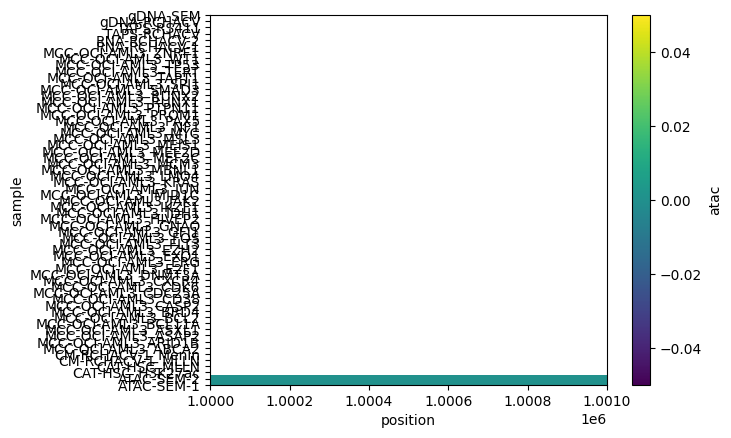

In [11]:
region["atac"].plot()  # x-axis = genomic coords

### Full genome 

→ xr.DataTree  (one node per chromosome)

In [12]:
tree = qn.to_datatree(chromosomes=["chr21"], lazy=True)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       chromsizes:  {'chr1': 248956422, 'chr10': 133797422, 'chr11': 135086622, ...
└── Group: /chr21
        Dimensions:       (sample: 61, position: 46709983)
        Coordinates:
          * sample        (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
          * position      (position) int64 374MB 1 2 3 4 ... 46709981 46709982 46709983
        Data variables: (12/61)
            AF            (sample, position) float32 11GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            atac          (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            cat           (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            chip          (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            coverage      (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            DP            (sample, position) float32 11GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            ...            ...
            mcc_ZNRF1     (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            methyl_pct    (sample, position) float32 11GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            MQ            (sample, position) float32 11GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            n_methylated  (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            n_total       (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            rna           (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>

In [13]:
tree["chr21"].ds.sel(position=slice(1_000_000, 2_000_000))

<xarray.Dataset> Size: 29GB
Dimensions:       (sample: 61, position: 1000001)
Coordinates:
  * sample        (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
  * position      (position) int64 8MB 1000000 1000001 ... 1999999 2000000
Data variables: (12/61)
    AF            (sample, position) float32 244MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    atac          (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    cat           (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    chip          (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    coverage      (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    DP            (sample, position) float32 244MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    ...            ...
    mcc_ZNRF1     (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    methyl_pct    (sample, position) float32 244MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    MQ            (sample, position) float32 244MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    n_methylated  (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    n_total       (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    rna           (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>

---
## Analysis

### Library sizes

Total mapped reads per sample, read from `metadata/total_reads` in each zarr store.

In [14]:
from quantnado.analysis.normalise import get_library_sizes

lib_sizes = get_library_sizes(qn)
lib_sizes

ATAC-SEM-1          110230100.0
ATAC-SEM-2           98190276.0
CAT-HSC_H3K27ac      14380122.0
CAT-HSC_MLLN          8924596.0
CM-RCHACV-1_MLLN     52277976.0
                       ...     
RNA-RCHACV-2         96917722.0
TAPS-RCHACV         279429253.0
TAPS-RS411          272059073.0
gDNA-RCHACV           4272920.0
gDNA-SEM              4882780.0
Name: library_size, Length: 61, dtype: float64

### Normalisation

CPM-normalise a coverage DataArray. Works on any `xr.DataArray`, `xr.Dataset`, or `pd.DataFrame`.

In [15]:
from quantnado.analysis.normalise import normalise

region = qn.sel(chrom="chr21", start=5_200_000, end=5_260_000)

# Normalise ATAC to CPM — library sizes are read automatically from the store
atac_cpm = normalise(region["atac"], qn, method="cpm")
atac_cpm

2026-04-09 17:20:03.945 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:546 - Normalised xr.DataArray to CPM.


<xarray.DataArray 'atac' (sample: 61, position: 60001)> Size: 29MB
dask.array<truediv, shape=(61, 60001), dtype=float64, chunksize=(1, 60001), chunktype=numpy.ndarray>
Coordinates:
  * sample    (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
  * position  (position) int64 480kB 5200000 5200001 5200002 ... 5259999 5260000
Attributes:
    normalised:  cpm

/Users/catherine/work/software/QuantNado/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


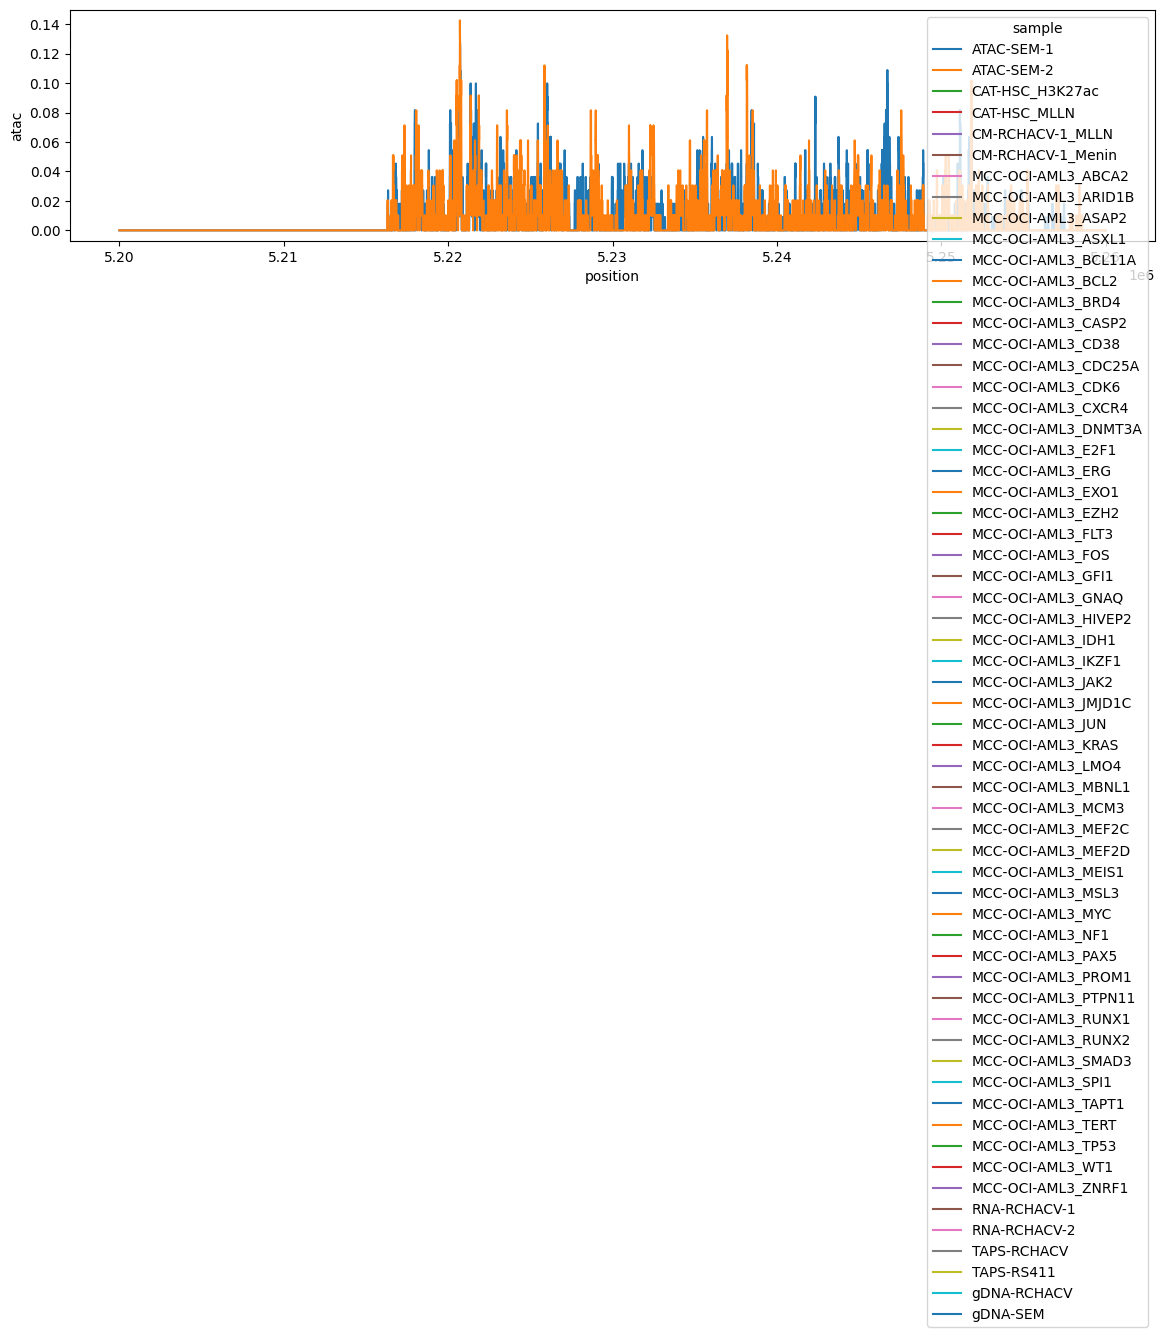

In [16]:
# Plot both samples in the region
atac_cpm.plot.line(x="position", hue="sample", figsize=(14, 3))

### Locus plot

Genome-browser style multi-track view. One track per sample, modality-aware rendering:
`coverage` → filled area, `stranded_coverage` → mirrored strands, `methylation` → scatter at CpG sites, `variant` → lollipop AF.

In [17]:
region = qn.sel(chrom="chr21", start=1_000_000, end=1_001_000)

# Check what's there
print(list(region.data_vars))

['AF', 'atac', 'cat', 'chip', 'coverage', 'DP', 'GT', 'mcc_ABCA2', 'mcc_ARID1B', 'mcc_ASAP2', 'mcc_ASXL1', 'mcc_BCL11A', 'mcc_BCL2', 'mcc_BRD4', 'mcc_CASP2', 'mcc_CD38', 'mcc_CDC25A', 'mcc_CDK6', 'mcc_CXCR4', 'mcc_DNMT3A', 'mcc_E2F1', 'mcc_ERG', 'mcc_EXO1', 'mcc_EZH2', 'mcc_FLT3', 'mcc_FOS', 'mcc_GFI1', 'mcc_GNAQ', 'mcc_HIVEP2', 'mcc_IDH1', 'mcc_IKZF1', 'mcc_JAK2', 'mcc_JMJD1C', 'mcc_JUN', 'mcc_KRAS', 'mcc_LMO4', 'mcc_MBNL1', 'mcc_MCM3', 'mcc_MEF2C', 'mcc_MEF2D', 'mcc_MEIS1', 'mcc_MSL3', 'mcc_MYC', 'mcc_NF1', 'mcc_PAX5', 'mcc_PROM1', 'mcc_PTPN11', 'mcc_RUNX1', 'mcc_RUNX2', 'mcc_SMAD3', 'mcc_SPI1', 'mcc_TAPT1', 'mcc_TERT', 'mcc_TP53', 'mcc_WT1', 'mcc_ZNRF1', 'methyl_pct', 'MQ', 'n_methylated', 'n_total', 'rna']


In [18]:
from quantnado.analysis.plot import locus_plot

locus = "chr21:5200000-5260000"
region = qn.sel(chrom="chr21", start=5_200_000, end=5_260_000)

locus_plot(
    locus=locus,
    sample_names=[
        "ATAC-SEM-1",
        "ATAC-SEM-2",
        "RNA-RCHACV-1",
        "RNA-RCHACV-2",
        "TAPS-RCHACV",
        "TAPS-RS411",
    ],
    modality=[
        "coverage",
        "coverage",
        "stranded_coverage",
        "stranded_coverage",
        "methylation",
        "methylation",
    ],
    coverage=region["atac"],
    coverage_fwd=region["rna_fwd"],
    coverage_rev=region["rna_rev"],
    methylation=region["methyl_pct"],
    figsize=(14, 10),
)

KeyError: "No variable named 'rna_fwd'. Did you mean one of ('rna',)?"

### Windowed signal matrix

Summarise signal in non-overlapping windows across chr21 — useful as input to `heatmap`, `correlate`, and `pca`.

In [ ]:

# 50 × 100 kb windows across chr21 starting at 5 Mb
window_size = 100_000
n_windows = 50
starts = [5_000_000 + i * window_size for i in range(n_windows)]

atac_samples = ["ATAC-SEM-1", "ATAC-SEM-2"]

rows = []
for start in starts:
    r = qn.sel(chrom="chr21", start=start, end=start + window_size)
    row = r["atac"].sel(sample=atac_samples).sum("position").values
    rows.append(row)

signal_df = pd.DataFrame(rows, columns=atac_samples, index=[f"chr21:{s // 1000}k" for s in starts])
signal_df.head()

### Heatmap

Clustered heatmap of signal across genomic windows × samples. Works on `reduce()` output, `count_features()` output, or any `pd.DataFrame` (rows = features, columns = samples).

In [ ]:
from quantnado.analysis.plot import heatmap

heatmap(signal_df, log_transform=True, title="ATAC signal — 100 kb windows (chr21)", figsize=(4, 8))

### Sample–sample correlation

In [ ]:
from quantnado.analysis.plot import correlate

corr_df, g = correlate(signal_df, log_transform=True, title="ATAC sample correlation")
corr_df

### PCA

`run_pca` takes a 2D `xr.DataArray` with a `sample` dimension. Here we use all 49 MCC viewpoints as samples, treating genomic positions as features — each viewpoint is a distinct chromatin contact profile.

In [ ]:
import xarray as xr

from quantnado.analysis.pca import plot_pca_scatter, plot_pca_scree, run_pca

# Get a large chr21 region covering all MCC viewpoint neighbourhoods
mcc_region = qn.sel(chrom="chr21", start=1_000_000, end=46_000_000)

# Stack all MCC viewpoint arrays into a single (n_viewpoints, n_positions) DataArray
mcc_keys = sorted(k for k in mcc_region.data_vars if k.startswith("mcc_"))
mcc_da = xr.concat([mcc_region[k] for k in mcc_keys], dim="sample")  # (49, n_pos)

print(f"Shape: {mcc_da.sizes}")
mcc_da

In [ ]:
pca_obj, pca_result = run_pca(
    mcc_da,
    n_components=5,
    nan_handling_strategy="set_to_zero",
    subset_size=50_000,  # subsample positions for speed
    subset_strategy="random",
    random_state=42,
)
pca_result

In [ ]:
plot_pca_scree(pca_obj)

In [ ]:
# Build a metadata DataFrame with viewpoint names as labels
viewpoint_names = [k[len("mcc_") :] for k in mcc_keys]
mcc_meta = pd.DataFrame(
    {
        "sample_id": [f"MCC-OCI-AML3_{vp}" for vp in viewpoint_names],
        "viewpoint": viewpoint_names,
    }
)

plot_pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=mcc_meta,
    colour_by=None,
    sample_column="sample_id",
)

### metaplot / tornadoplot

Require `qn.extract()` — anchors signal around genomic features from a GTF file, returning a `(interval, bin, sample)` DataArray.

In [ ]:
from quantnado.analysis.plot import metaplot, tornadoplot

binned = qn.extract(
    feature_type="promoter",
    GTF_FILE=GTF_FILE,
    fixed_width=4000,
    anchor="start",
    bin_size=50,
    assay="atac",
)

# CPM-normalise first
binned_cpm = normalise(binned, qn, method="cpm")

# Metaplot: average signal profile across all intervals
metaplot(
    binned_cpm,
    modality="coverage",
    groups={"SEM": ["ATAC-SEM-1", "ATAC-SEM-2"]},
    title="ATAC signal at promoters",
)

# Tornadoplot: heatmap with one row per interval, sorted by signal strength
tornadoplot(
    binned_cpm,
    modality="coverage",
    samples=["ATAC-SEM-1", "ATAC-SEM-2"],
    title="ATAC signal at promoters",
)

### Feature counts (DESeq2-compatible)

Count signal over genes/exons from a GTF file. Returns a `(genes × samples)` integer count matrix.

In [ ]:
from quantnado.analysis.counts import count_features

# Count ATAC signal over gene bodies
counts, features = count_features(
    qn,
    gtf_file=GTF_FILE,
    feature_type="gene",
    assay="atac",
)
# counts: pd.DataFrame — rows=genes, columns=samples (integer counts)
# features: pd.DataFrame — gene metadata (chrom, start, end, length)

# Normalise to RPKM
rpkm = normalise(counts, qn, method="rpkm", feature_lengths=features["range_length"])

# Heatmap of top variable genes
heatmap(counts, log_transform=True, title="Gene-level ATAC signal")